# **Set Up**

In [1]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 9.9 MB/s eta 0:00:00


In [2]:
# rdkit for chemistry processing
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors, MACCSkeys
from rdkit.ML.Descriptors import MoleculeDescriptors
from sklearn import preprocessing

import numpy as np
import pandas as pd

import math
import matplotlib.colors
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.transforms as mtransforms
import seaborn as sns

import os
import tempfile
import shutil
from tqdm import tqdm
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from google.colab import files

In [3]:
sns.set(font_scale=1.5)
sns.set_style('whitegrid')

# **Standard SlogP Plotting**

In [ ]:
# load your file as a dataframe

Lipo = pd.read_excel("APIvsProdrugsLipoSlogPGen1Mil.xlsx")
Sol = pd.read_excel("APIvsProdrugsSolSlogPGen1Mil.xlsx")

# check the your data frame by showing the first 5 entries
Sol.head()

,SlogPAPI,SlogFDAProdrug,SlogGenProdrug,X1,X2,X3
0,1.5576,1.6746,-7.81801,1,1,1
1,5.3500,4.3655,-13.81675,2,2,2
2,5.1820,5.2990,-4.19361,3,3,3
3,-1.8409,-1.7239,-11.21651,4,4,4
4,1.7696,1.5488,-7.94381,5,5,5


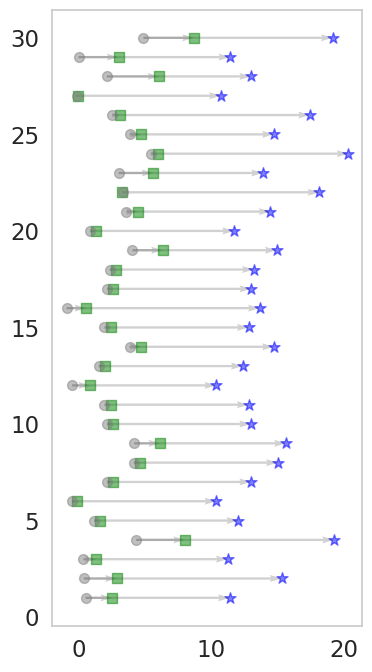

In [ ]:
fig, ax = plt.subplots()
ax.scatter(Lipo['SlogPAPI'], Lipo['X1'], c = 'grey', marker = 'o', s = 50, zorder = 3, alpha = 0.5)
ax.scatter(Lipo['SlogFDAProdrug'], Lipo['X2'], c = 'green', marker = 's', s = 50, zorder = 2, alpha = 0.5)
ax.scatter(Lipo['SlogGenProdrug'], Lipo['X3'], c = 'blue', marker = '*', s = 70, zorder = 1, alpha = 0.5)

ax.quiver(Lipo['SlogPAPI'], Lipo['X1'], (Lipo['SlogFDAProdrug']-Lipo['SlogPAPI']), (Lipo['X2']-Lipo['X1']), angles='xy', scale_units='xy', scale=1, alpha = 0.2)
ax.quiver(Lipo['SlogPAPI'], Lipo['X1'], (Lipo['SlogGenProdrug']-Lipo['SlogPAPI']), (Lipo['X3']-Lipo['X1']), angles='xy', scale_units='xy', scale=1, alpha = 0.2)

#plt.xlim([-700, 2400])
#plt.ylim([-230, 350])
fig.set_size_inches(4, 8)
ax.grid(False)
plt.savefig('Lipo_SlogP.svg')



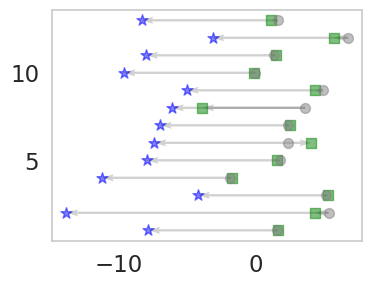

In [ ]:
fig, ax = plt.subplots()
ax.scatter(Sol['SlogPAPI'], Sol['X1'], c = 'grey', marker = 'o', s = 50, zorder = 3, alpha = 0.5)
ax.scatter(Sol['SlogFDAProdrug'], Sol['X2'], c = 'green', marker = 's', s = 50, zorder = 2, alpha = 0.5)
ax.scatter(Sol['SlogGenProdrug'], Sol['X3'], c = 'blue', marker = '*', s = 70, zorder = 1, alpha = 0.5)

ax.quiver(Sol['SlogPAPI'], Sol['X1'], (Sol['SlogFDAProdrug']-Sol['SlogPAPI']), (Sol['X2']-Sol['X1']), angles='xy', scale_units='xy', scale=1, alpha = 0.2)
ax.quiver(Sol['SlogPAPI'], Sol['X1'], (Sol['SlogGenProdrug']-Sol['SlogPAPI']), (Sol['X3']-Sol['X1']), angles='xy', scale_units='xy', scale=1, alpha = 0.2)

#plt.xlim([-700, 2400])
#plt.ylim([-230, 350])
fig.set_size_inches(4, 3)
ax.grid(False)
plt.savefig('Sol_SlogP.svg')

# **Delta Plotting for Predictions**

In [ ]:
# load your file as a dataframe

Lipo = pd.read_excel("APIvsProdrugsLipoGen.xlsx")
Sol = pd.read_excel("APIvsProdrugsSolGen.xlsx")

# check the your data frame by showing the first 5 entries
Sol.head()

,API,FDAProdrug,GenProdrug,X1,X2,X3
0,0,0.601195,3.709862,1,1,1
1,0,0.643518,4.687421,2,2,2
2,0,1.346469,4.397591,3,3,3
3,0,-0.043687,3.070489,4,4,4
4,0,1.223775,4.137702,5,5,5


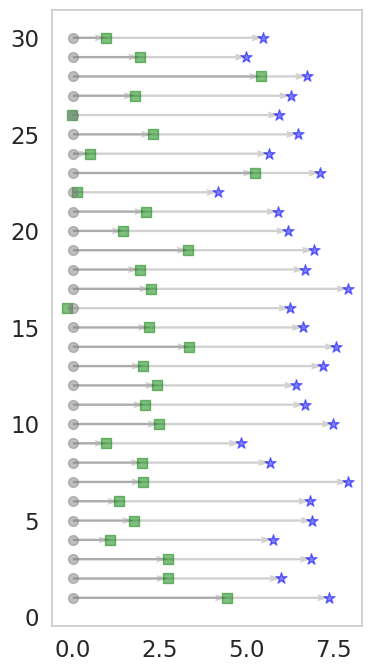

In [ ]:
fig, ax = plt.subplots()
ax.scatter(Lipo['API'], Lipo['X1'], c = 'grey', marker = 'o', s = 50, zorder = 3, alpha = 0.5)
ax.scatter(Lipo['FDAProdrug'], Lipo['X2'], c = 'green', marker = 's', s = 50, zorder = 2, alpha = 0.5)
ax.scatter(Lipo['GenProdrug'], Lipo['X3'], c = 'blue', marker = '*', s = 70, zorder = 1, alpha = 0.5)

ax.quiver(Lipo['API'], Lipo['X1'], (Lipo['FDAProdrug']-Lipo['API']), (Lipo['X2']-Lipo['X1']), angles='xy', scale_units='xy', scale=1, alpha = 0.2)
ax.quiver(Lipo['API'], Lipo['X1'], (Lipo['GenProdrug']-Lipo['API']), (Lipo['X3']-Lipo['X1']), angles='xy', scale_units='xy', scale=1, alpha = 0.2)

#plt.xlim([-700, 2400])
#plt.ylim([-230, 350])
fig.set_size_inches(4, 8)
ax.grid(False)
plt.savefig('Lipo_Delta.svg')

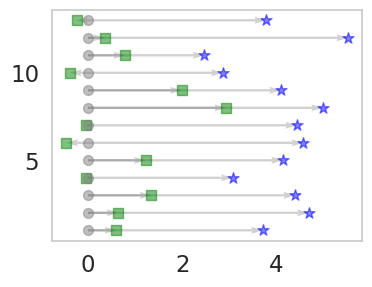

In [ ]:
fig, ax = plt.subplots()
ax.scatter(Sol['API'], Sol['X1'], c = 'grey', marker = 'o', s = 50, zorder = 3, alpha = 0.5)
ax.scatter(Sol['FDAProdrug'], Sol['X2'], c = 'green', marker = 's', s = 50, zorder = 2, alpha = 0.5)
ax.scatter(Sol['GenProdrug'], Sol['X3'], c = 'blue', marker = '*', s = 70, zorder = 1, alpha = 0.5)

ax.quiver(Sol['API'], Sol['X1'], (Sol['FDAProdrug']-Sol['API']), (Sol['X2']-Sol['X1']), angles='xy', scale_units='xy', scale=1, alpha = 0.2)
ax.quiver(Sol['API'], Sol['X1'], (Sol['GenProdrug']-Sol['API']), (Sol['X3']-Sol['X1']), angles='xy', scale_units='xy', scale=1, alpha = 0.2)

#plt.xlim([-700, 2400])
#plt.ylim([-230, 350])
fig.set_size_inches(4, 3)
ax.grid(False)
plt.savefig('Sol_Delta.svg')

# **t-SNE of Chemical Structures of Exisiting and Generated Promoieties**

In [4]:
# Functions for visualizing chemical space from: https://practicalcheminformatics.blogspot.com/2019/11/visualizing-chemical-space.html

sns.set(rc={'figure.figsize': (10, 10)})
sns.set(font_scale=1.5)
sns.set_style('whitegrid')

def fp_list_from_smiles_list(smiles_list, n_bits=2048):
    fp_list = []
    for smiles in tqdm(smiles_list):
        mol = Chem.MolFromSmiles(smiles)
        if mol == None:
            continue
        fp_list.append(fp_as_array(mol, n_bits))
    return fp_list

def fp_as_array(mol,n_bits=2048):
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, 2, nBits=n_bits)
    arr = np.zeros((1,), int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


In [5]:
# Combine various groups together and label types
df1 = pd.read_csv('PurchasableFragments.csv')
df1['Type'] = 'Fragment'
df2 = pd.read_csv('UniquePromoietiesOfFDAProdrugs.csv')
df2['Type'] = 'Approved'
df3 = pd.read_csv('InvestigationalProdrugPromoieties.csv')
df3['Type'] = 'Investigational'

dfGRU1 = pd.read_csv('GRU_MolganInput_1.csv')
dfGRU1['Type'] = 'GRU'
dfGRU2 = pd.read_csv('GRU_MolganInput_2.csv')
dfGRU2['Type'] = 'GRU'
dfGRU3 = pd.read_csv('GRU_MolganInput_3.csv')
dfGRU3['Type'] = 'GRU'


df = pd.concat([df1, df2, df3, dfGRU1, dfGRU2, dfGRU3])
df = df.reset_index(drop=True)
dataset = 'all_data_tSNE'
df.to_csv('{}.csv'.format(dataset), index = False)

In [ ]:
# Actual t-SNE

# Convert to fingerprints and perform a PCA down to 50 components for efficiency
fp_list = fp_list_from_smiles_list(df.SMILES)
pca = PCA(n_components=50)
crds = pca.fit_transform(fp_list)

# Perform t-SNE on the PCA
%time crds_embedded = TSNE(n_components=2).fit_transform(crds)
tsne_df = pd.DataFrame(crds_embedded,columns=["X","Y"])
tsne_df['SMILES'] = df['SMILES']
tsne_df['Type'] = df['Type']
tsne_2 = df.merge(tsne_df, left_on=['SMILES', 'Type'], right_on=['SMILES', 'Type'])

tsne_2.to_csv('{}_promoiety_analysis.csv'.format(dataset), index = False)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

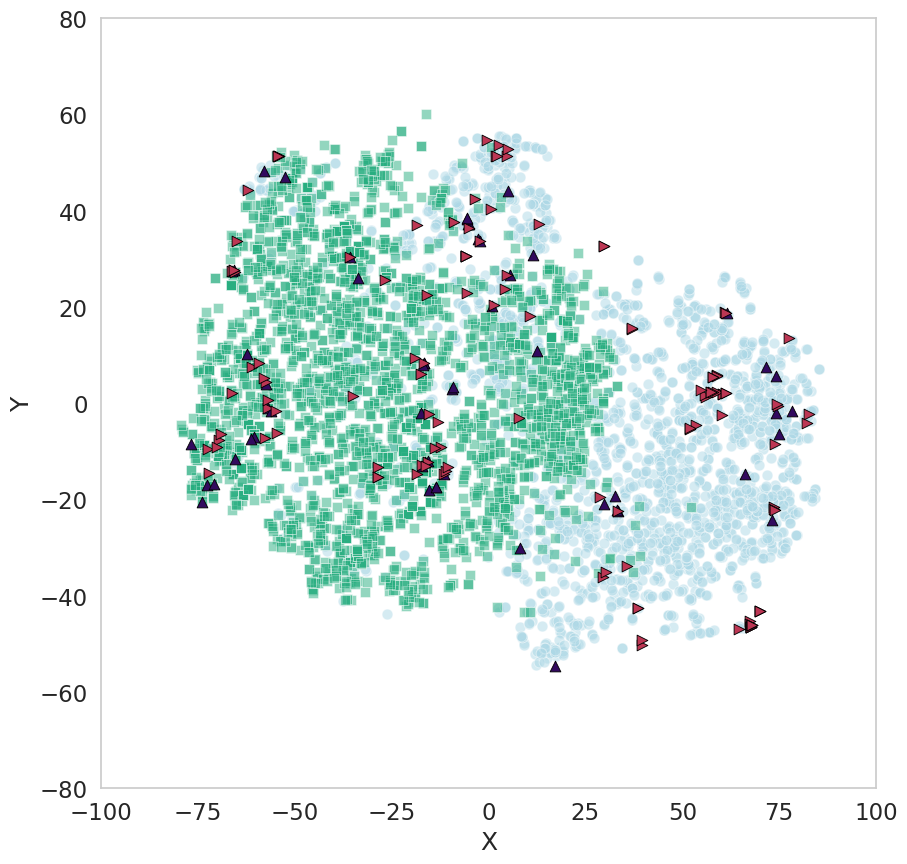

In [9]:
# Plotting
fig= plt.figure()

# Get datasets
Fragment = tsne_2[tsne_2['Type'] == 'Fragment']
Approved = tsne_2[tsne_2['Type'] == 'Approved']
Investigational = tsne_2[tsne_2['Type'] == 'Investigational']
GRU = tsne_2[tsne_2['Type'] == 'GRU']
LLM = tsne_2[tsne_2['Type'] == 'LLM']

# Plot
ax = sns.scatterplot(data=Fragment,x="X",y="Y", color='lightblue', s=60, alpha = 0.5)
ax = sns.scatterplot(data=LLM,x="X",y="Y",color='#FF8C00', marker = 'D', s=60, alpha = 0.5)
ax = sns.scatterplot(data=GRU,x="X",y="Y",color='#28ae80', marker = 's', s=60, alpha = 0.5)
ax = sns.scatterplot(data=Approved,x="X",y="Y",color='#320a5e', edgecolor = 'black', marker = '^', s=60)
ax = sns.scatterplot(data=Investigational,x="X",y="Y",color='#bc3754', edgecolor = 'black', marker = '>', s=60)


ax.set_xlim([-100, 100])
ax.set_ylim([-80, 80])

#plt.savefig("all_t-SNE.png", facecolor='white')
#files.download("all_t-SNE.png")
plt.grid()
plt.show()